# DeepRL Usage Tutorial

In [1]:
# Uncomment below lines and run this cell to install neuronav and requirements for colab.

#!git clone https://github.com/awjuliani/neuro-nav
#!pip install ./neuro-nav[experiments_remote]

In [2]:
from neuronav.envs.grid_env import GridEnv, GridSize, GridObsType, OrientationType
from neuronav.agents.deep_agents import PGAgent
from neuronav.envs.grid_topographies import GridTopography
from neuronav.utils import run_episode
import matplotlib.pyplot as plt

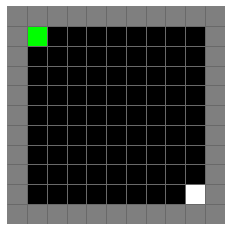

In [3]:
num_episodes = 2000
num_steps = 100

env = GridEnv(
    topography=GridTopography.empty,
    grid_size=GridSize.small,
    obs_type=GridObsType.geometric,
    orientation_type=OrientationType.fixed,
)
obs = env.reset()
env.render()

agent = PGAgent(
    env.observation_space.shape[-1],
    env.action_space.n,
    lr=3e-4,
    poltype="softmax",
    beta=1.0,
    gamma=0.9,
)

Text(0, 0.5, 'Time-steps')

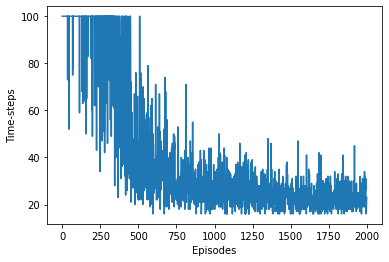

In [4]:
total_steps = []
for i in range(num_episodes):
    obs = env.reset()
    steps = 0
    done = False
    while not done and steps < num_steps:
        act = agent.sample_action(obs)
        obs_new, reward, done, _ = env.step(act)
        agent.update([obs, act, obs_new, reward, done])
        obs = obs_new
        steps += 1
    total_steps.append(steps)
plt.plot(total_steps)
plt.xlabel("Episodes")
plt.ylabel("Time-steps")